In [1]:
# %% Import the libraries we need
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import numpy as np

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

# Optional: inspect the first rows
dataset.head()


,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,country,solar_layout_MW,wind_layout_MW
0,2012-01-01 00:00:00+00:00,1,75.6549,9.150821,0.0,18.301642,0.0,0.0284,42.094674,-8.113982,POR,982.8607,644.4240
1,2012-01-01 00:00:00+00:00,2,557.8868,6.196411,0.0,12.392822,0.0,0.0103,41.587435,-8.326462,POR,1361.0601,1203.1866
2,2012-01-01 00:00:00+00:00,3,15.5237,6.855084,0.0,13.710167,0.0,0.0283,41.585994,-6.722728,POR,746.4879,484.4582
3,2012-01-01 00:00:00+00:00,4,8.6425,7.824092,0.0,15.648183,0.0,0.0408,41.597684,-6.342848,POR,456.1251,383.5339
4,2012-01-01 00:00:00+00:00,5,85.3649,2.053690,0.0,4.107380,0.0,0.0092,41.373957,-7.350949,POR,986.4986,446.4544


In [2]:
def maxima_values(series):
    peak_indices, _ = find_peaks(series)
    return series[peak_indices]
def minima_values(series):
    peak_indices, _ = find_peaks(series * -1)
    return series[peak_indices]


Text(0.5, 1.0, 'Next power peak against current peak (Node ID=1)')

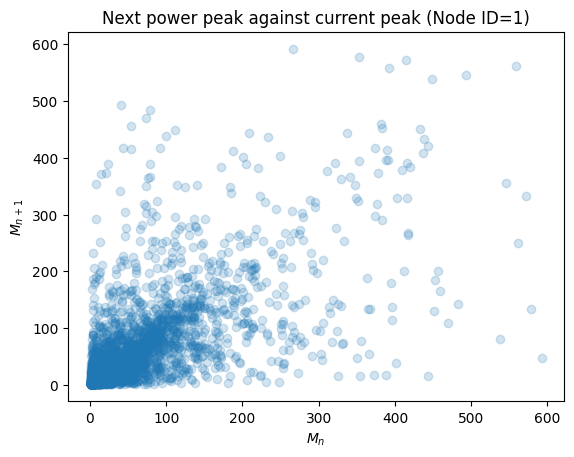

In [3]:
M_true = minima_values(dataset[(dataset["ID"]=="1")]["wind_MWh"].to_numpy())
plt.scatter(M_true[:-1], M_true[1:], alpha=0.2)
plt.xlabel(r"$M_{n}$")
plt.ylabel(r"$M_{n+1}$")
plt.title("Next power peak against current peak (Node ID=1)")

Text(0.5, 1.0, 'Next power peak against current peak (Node ID=1)')

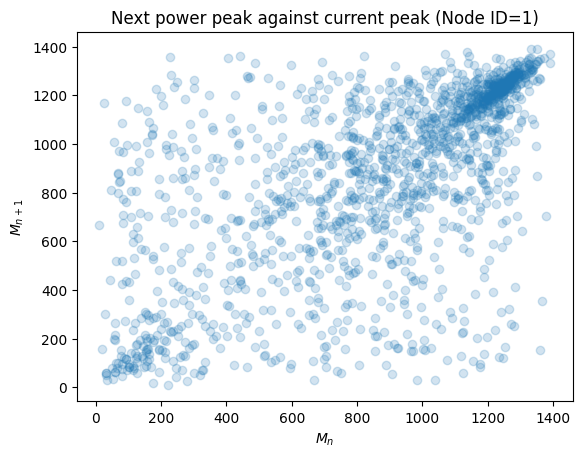

In [4]:
M_true = maxima_values(dataset[(dataset["ID"]=="1")]["solar_MWh"].to_numpy())
plt.scatter(M_true[:-1], M_true[1:], alpha=0.2)
plt.xlabel(r"$M_{n}$")
plt.ylabel(r"$M_{n+1}$")
plt.title("Next power peak against current peak (Node ID=1)")

In [5]:
dataset['row'] = dataset.groupby('ID').cumcount()

cols = dataset['ID'].unique()

out = dataset.pivot(index='row', columns='ID', values='demand_MWh')
out = out.reindex(columns=cols)


In [6]:
id_corrmat = out[out.columns[1:1000]].corr()

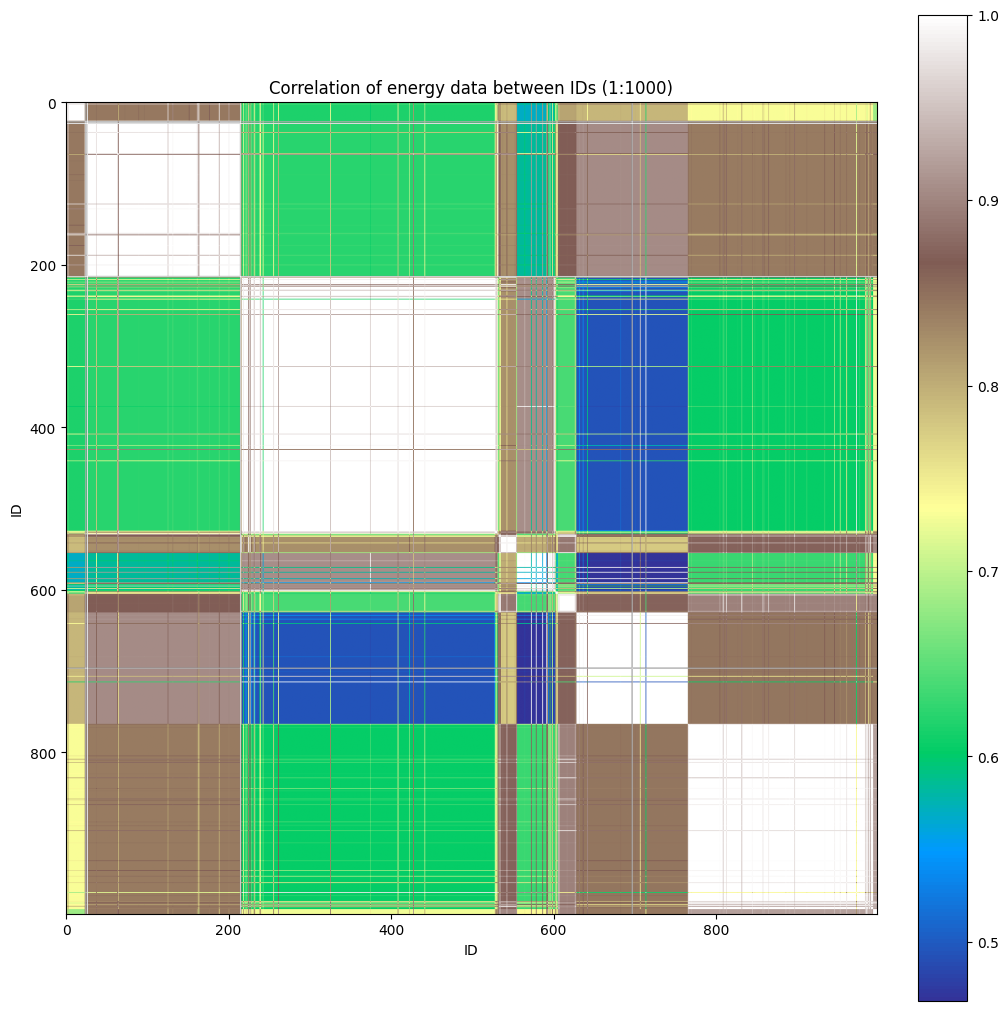

In [7]:
fig, ax = plt.subplots(figsize=(10,10), layout="constrained")
im = ax.imshow(id_corrmat, cmap="terrain")
ax.set_xlabel("ID")
ax.set_ylabel("ID")
fig.colorbar(im, ax=ax)
plt.title("Correlation of energy data between IDs (1:1000)")
plt.show()

In [24]:
plot_data = dataset[dataset["ID"]=="1"][["Time", "solar_MWh", "wind_MWh"]]

In [25]:
plot_data['hour'] = plot_data['Time'].apply(lambda x: x.hour)

In [26]:
plot_data['date'] = pd.to_datetime(plot_data['Time'].apply(lambda x: x.date()))

In [27]:
solar_gen_data = plot_data.pivot(columns="hour", index="date", values = "solar_MWh")

In [28]:
import plotnine as gg

In [29]:
def custom_label_date(x):
    return [
        d.strftime("%d-%b") if d.day == 1 else str(d.day)
        for d in x
    ]

def custom_label_time(x):
    out = []
    for h in x:
        if int(h)==0:
            out.append("12 AM")
        elif int(h)==12:
            out.append("12 PM")
        else:
            out.append(
                str(int(h) % 12)
            )
    return out

In [30]:
plot_data

,Time,solar_MWh,wind_MWh,hour,date
0,2012-01-01 00:00:00+00:00,0.0,18.301642,0,2012-01-01
1494,2012-01-01 01:00:00+00:00,0.0,21.652646,1,2012-01-01
2988,2012-01-01 02:00:00+00:00,0.0,25.261421,2,2012-01-01
4482,2012-01-01 03:00:00+00:00,0.0,27.323578,3,2012-01-01
5976,2012-01-01 04:00:00+00:00,0.0,30.610140,4,2012-01-01
...,...,...,...,...,...
39290706,2014-12-31 19:00:00+00:00,0.0,6.830894,19,2014-12-31
39292200,2014-12-31 20:00:00+00:00,0.0,8.506397,20,2014-12-31
39293694,2014-12-31 21:00:00+00:00,0.0,7.539761,21,2014-12-31
39295188,2014-12-31 22:00:00+00:00,0.0,6.766452,22,2014-12-31


In [31]:
    # + gg.scale_fill_gradient2(low = "blue", mid = "white", high = "red") \
p = gg.ggplot(
    plot_data[(plot_data["date"] >= pd.to_datetime("2012-01-01")) &  (plot_data["date"] <= pd.to_datetime("2012-02-01"))],
    gg.aes(
        x="hour",
        y="date",
        fill="wind_MWh",
    )
) \
    + gg.geom_raster() \
    + gg.scale_fill_continuous("coolwarm") \
    + gg.theme_minimal() \
    + gg.geom_tile(color = "white", size = 0.5) \
    + gg.theme(legend_position="top",
                panel_grid_major = gg.element_blank(),
                panel_grid_minor = gg.element_blank(),
                panel_border = gg.element_blank(),
                panel_background = gg.element_blank(),
                figure_size=(10,10)) \
    + gg.scale_y_datetime(
        breaks=pd.date_range("2012-01-01","2012-02-01"),
        labels=custom_label_date) \
    + gg.scale_x_continuous(
        breaks=np.arange(0,24),
        labels=custom_label_time
    )

p.save("jan12")

/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: jan12


In [48]:
months = [
    "2012-01-01", "2012-02-01", "2012-03-01", "2012-04-01", "2012-05-01", "2012-06-01", "2012-07-01","2012-08-01","2012-09-01","2012-10-01","2012-11-01","2012-12-01",
          "2013-01-01", "2013-02-01", "2013-03-01", "2013-04-01", "2013-05-01", "2013-06-01", "2013-07-01","2013-08-01","2013-09-01","2013-10-01","2013-11-01","2013-12-01",
          "2014-01-01", "2014-02-01", "2014-03-01", "2014-04-01", "2014-05-01", "2014-06-01", "2014-07-01","2014-08-01","2014-09-01","2014-10-01","2014-11-01","2014-12-01", "2014-12-31"]


In [49]:
plot_data["wind_MWh"].min()

np.float64(0.8377511999999999)

In [50]:
for idx, month in enumerate(months):
    if idx==36:
        break
    p = gg.ggplot(
    plot_data[(plot_data["date"] >= pd.to_datetime(month)) &  (plot_data["date"] <= pd.to_datetime(months[idx+1]))],
    gg.aes(
        x="hour",
        y="date",
        fill="wind_MWh",
    )
) \
    + gg.geom_raster() \
    + gg.scale_fill_continuous("coolwarm", limits=(0,650)) \
    + gg.theme_minimal() \
    + gg.geom_tile(color = "white", size = 0.5) \
    + gg.theme(legend_position="top",
                panel_grid_major = gg.element_blank(),
                panel_grid_minor = gg.element_blank(),
                panel_border = gg.element_blank(),
                panel_background = gg.element_blank(),
                figure_size=(10,10)) \
    + gg.scale_y_datetime(
        breaks=pd.date_range(month,months[idx+1]),
        labels=custom_label_date) \
    + gg.scale_x_continuous(
        breaks=np.arange(0,24),
        labels=custom_label_time
    ) \
    + gg.labs(
        x="Time of day",
        y="Date",
        title=month.split("-")[0],
        fill="Wind production")

    p.save(month, dpi=300)

/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: 2012-01-01
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: 2012-02-01
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: 2012-03-01
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site

In [51]:
import imageio.v2 as imageio

In [52]:
months = [
    "2012-01-01", "2012-02-01", "2012-03-01", "2012-04-01", "2012-05-01", "2012-06-01", "2012-07-01","2012-08-01","2012-09-01","2012-10-01","2012-11-01","2012-12-01",
          "2013-01-01", "2013-02-01", "2013-03-01", "2013-04-01", "2013-05-01", "2013-06-01", "2013-07-01","2013-08-01","2013-09-01","2013-10-01","2013-11-01","2013-12-01",
          "2014-01-01", "2014-02-01", "2014-03-01", "2014-04-01", "2014-05-01", "2014-06-01", "2014-07-01","2014-08-01","2014-09-01","2014-10-01","2014-11-01","2014-12-01"]
fnames = [f"{i}.png" for i in months]

In [ ]:
with imageio.get_writer('animation.gif', mode='I') as writer:
    for filename in fnames:
        image = imageio.imread(filename)
        writer.append_data(image)

print("GIF saved as animation.gif")

GIF saved as animation.gif


In [54]:
images = [imageio.imread(fname) for fname in fnames]

def crossfade_frames(images, steps=5):
    blended = []

    for i in range(len(images) - 1):
        A = images[i].astype(float)
        B = images[i + 1].astype(float)

        blended.append(images[i])  # original frame

        # Create intermediate frames
        for t in np.linspace(0, 1, steps, endpoint=False)[1:]:
            frame = (1 - t) * A + t * B
            blended.append(frame.astype(np.uint8))

    blended.append(images[-1])
    return blended


# Apply crossfade
smooth_images = crossfade_frames(images, steps=6)

# Save GIF
imageio.mimsave("smooth_animation.gif", smooth_images, duration=0.08)

In [59]:
imageio.mimsave(
    "animation.gif",
    images,
    duration=0.2  # seconds per frame
)